# Week 12 Exercise ( A mini-project)

Using the machine or deep learning algorithms, build at least three classification models for the movie review dataset.
1.  Carry out exploratory analysis of the dataset using python analytics tools.
2.  You are required to check for class imbalance. Should there be class imbalance issue, use relevant technique to balance the labelled set (please give reason/s for choice of technique and show awareness of alternative methods).
3.  Evaluate and compare the performance of the classification models using relevant methods and metrics.
4.  Which of the models are you likely to deploy, and why?
(HINT: Remember your Numpy, Pandas, Matplotlib, Seaborn, Scikit-learn libraries.)


In [1]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
import re
import string
import unicodedata
import warnings

from bs4 import BeautifulSoup
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
from textblob import TextBlob

# Ignore warnings for cleaner output
warnings.filterwarnings('ignore')

In [2]:
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords') # Download the stopwords dataset

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
# Load the dataset
df = pd.read_csv("moviereview.csv")

# Display the shape and first few rows
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


(50000, 2)
Index(['review', 'sentiment'], dtype='object')


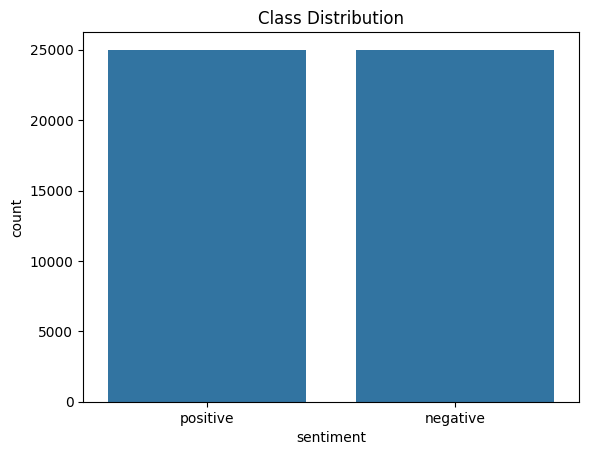

sentiment
positive    50.0
negative    50.0
Name: proportion, dtype: float64


In [4]:
#1) EDA:
# Basic info
print(df.shape)
print(df.columns)
df.head()

# Check for null values
df.isnull().sum()

# Distribution of sentiment labels (for class imbalance)
# Assuming 'sentiment' is the correct column name for sentiment labels
sns.countplot(data=df, x='sentiment') # Changed 'label' to 'sentiment'
plt.title('Class Distribution')
plt.show()

# Percentage distribution
# Assuming 'sentiment' is the correct column name for sentiment labels
print(df['sentiment'].value_counts(normalize=True) * 100) # Changed 'label' to 'sentiment'

In [5]:
#2) Preprocessing the Text:
# Example cleaning function
def clean_text(text):
    text = BeautifulSoup(text, "html.parser").get_text()  # remove HTML
    text = re.sub(r"[^a-zA-Z]", " ", text)  # keep only letters
    text = text.lower()
    text = word_tokenize(text)
    text = [word for word in text if word not in stopwords.words('english')]
    text = " ".join(text)
    return text

df['clean_review'] = df['review'].apply(clean_text)

In [6]:
#3) Handle Class Imbalance data:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['clean_review'])
# The column name for sentiment labels is 'sentiment', not 'label'
y = df['sentiment'] # Changed 'label' to 'sentiment'

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [7]:
#4) Model Building:

# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train_res, y_train_res)
y_pred_lr = lr.predict(X_test)

In [8]:
# Naive Bayes
nb = MultinomialNB()
nb.fit(X_train_res, y_train_res)
y_pred_nb = nb.predict(X_test)

In [9]:
# SVM
svm = SVC(kernel='linear')
svm.fit(X_train_res, y_train_res)
y_pred_svm = svm.predict(X_test)

In [10]:
#5) Model Evaluation:

def evaluate_model(y_test, y_pred, model_name):
    print(f"----- {model_name} -----")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

evaluate_model(y_test, y_pred_lr, "Logistic Regression")
evaluate_model(y_test, y_pred_nb, "Naive Bayes")
evaluate_model(y_test, y_pred_svm, "SVM")

----- Logistic Regression -----
Accuracy: 0.8888
[[4404  596]
 [ 516 4484]]
              precision    recall  f1-score   support

    negative       0.90      0.88      0.89      5000
    positive       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

----- Naive Bayes -----
Accuracy: 0.8553
[[4257  743]
 [ 704 4296]]
              precision    recall  f1-score   support

    negative       0.86      0.85      0.85      5000
    positive       0.85      0.86      0.86      5000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000

----- SVM -----
Accuracy: 0.8853
[[4405  595]
 [ 552 4448]]
              precision    recall  f1-score   support

    negative       0.89      0.88      0.88      5000
    positive       0.88      0.89